# Plot model training losses

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 

import sys
import pickle as pk
from sklearn.decomposition import PCA
import torch

sys.path.append('/home/nuttidalab/Documents/spikeRNN/rate/')
# import model
from model import generate_input_stim_xor, eval_tf

# sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/utils/')
# import vis_utils as vu
# import trajectory_utils as tu
import importlib

/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
2025-03-12 17:09:31.993369: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-12 17:09:32.002426: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-12 17:09:32.011941: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register facto

Instructions for updating:
non-resource variables are not supported in the long term


In [6]:
models_types = ['good_models','bad_models']

all_losses = []
for models_type in models_types:
    print(f'Analyzing {models_type}')
    
    models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved

    model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
    model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
    model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

    losses = []
    for i_model in range(len(model_list)):
        model_path = os.path.join(models_dir, model_list[i_model])
        model = scipy.io.loadmat(model_path)
        losses.append(model['losses'][0])
    all_losses.append(losses)


Analyzing good_models
Analyzing bad_models


In [8]:
good_colors = ['#007a7a','#004747']
bad_colors = ['#7a007a', '#470047']

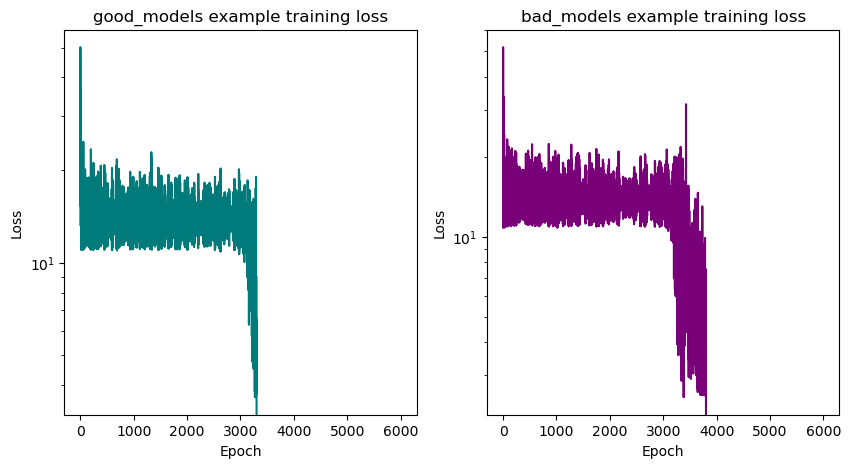

In [13]:
# plot an example loss curve for each model type

colors = [good_colors[0], bad_colors[0]]

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
for i, models_type in enumerate(models_types):
    axs[i].plot(all_losses[i][0], color=colors[i])
    axs[i].set_title(f'{models_type} example training loss')
    axs[i].set_xlabel('Epoch')
    axs[i].set_ylabel('Loss')
    axs[i].set_yscale('log')
plt.show()


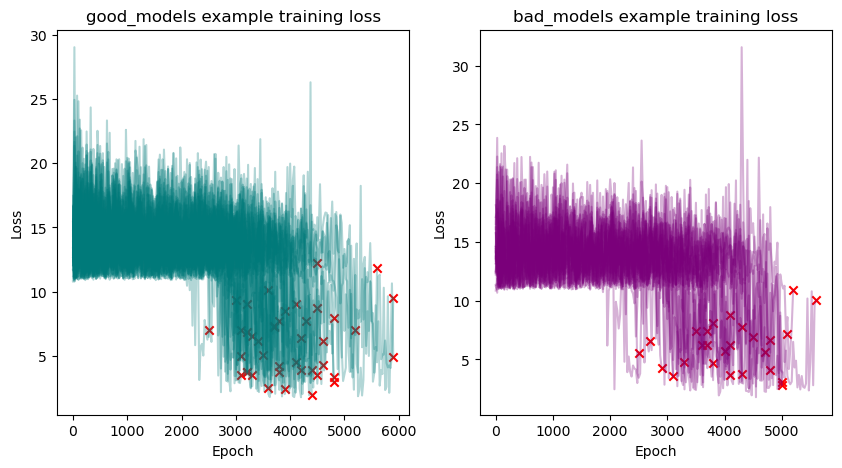

In [31]:
# plot an example loss curve for each model type

colors = [good_colors[0], bad_colors[0]]

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
for i, models_type in enumerate(models_types):
    for j in range(len(all_losses[i])):
        # loss = all_losses[i][j]
        # n_train_trials = len(loss[loss != 0])
        # x_range = range(len(loss))
        x_range = range(len(all_losses[i][j]))
        x_skip = 25
        new_x_range = x_range[::x_skip]
        new_losses = all_losses[i][j][::x_skip]

        train_end_idx = len(new_losses[new_losses != 0])

        axs[i].plot(new_x_range[:train_end_idx], new_losses[:train_end_idx], color=colors[i], alpha=0.3)
        
        axs[i].scatter(new_x_range[train_end_idx-1], new_losses[train_end_idx-1], color='r', marker='x')
        # break
    axs[i].set_title(f'{models_type} example training loss')
    axs[i].set_xlabel('Epoch')
    axs[i].set_ylabel('Loss')
    # axs[i].set_yscale('log')
plt.show()


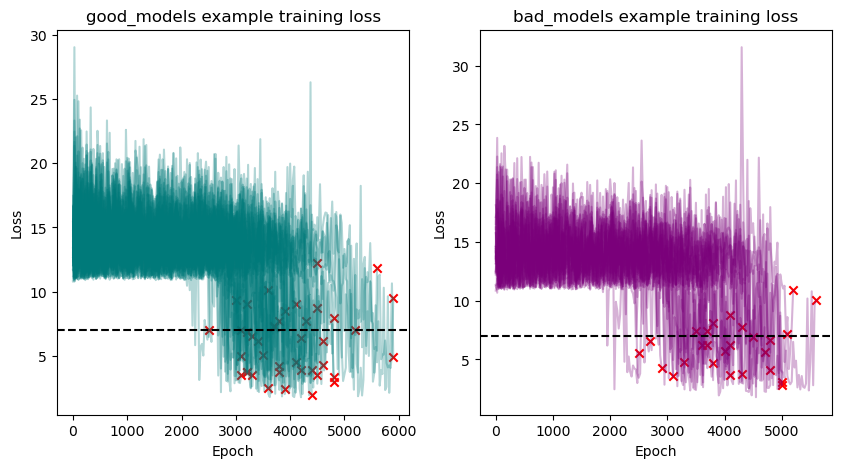

In [35]:
# plot an example loss curve for each model type

colors = [good_colors[0], bad_colors[0]]

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
for i, models_type in enumerate(models_types):
    for j in range(len(all_losses[i])):
        # loss = all_losses[i][j]
        # n_train_trials = len(loss[loss != 0])
        # x_range = range(len(loss))
        x_range = range(len(all_losses[i][j]))
        x_skip = 25
        new_x_range = x_range[::x_skip]
        new_losses = all_losses[i][j][::x_skip]

        train_end_idx = len(new_losses[new_losses != 0])

        axs[i].plot(new_x_range[:train_end_idx], new_losses[:train_end_idx], color=colors[i], alpha=0.3)
        
        axs[i].scatter(new_x_range[train_end_idx-1], new_losses[train_end_idx-1], color='r', marker='x')
        # break
    axs[i].set_title(f'{models_type} example training loss')
    axs[i].set_xlabel('Epoch')
    axs[i].set_ylabel('Loss')
    axs[i].axhline(7, color='k', linestyle='--')
    # axs[i].set_yscale('log')
plt.show()
